# Method C: Hilbert-Curve Signature Distance

A single space-filling curve through the image, in place of Method B's 16 straight
reference lines: an order-5 Hilbert curve (1024 cells on a 32x32 grid), scaled into the
28x28 image domain and resampled to 512 points evenly spaced along its arc length, then
cut into 16 contiguous segments of 32 points each - the same total point budget as
Method B's current default (16 lines x 32 points), so the two methods can be compared
fairly. Each segment gets its own signature and its own local Lipschitz ratio, following
the same per-path (never-merged) evaluation approach used for Method B - the 16 segments
are examined as a collection, never combined into a single vector before comparison.

Everything downstream of stream construction reuses Method B's existing infrastructure
unchanged: signature computation, level-rescaling, the per-segment distance function, the
adversarial evaluation machinery, and the same/different-digit AUC diagnostic.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

%load_ext autoreload
%autoreload 2

%matplotlib inline
import matplotlib.pyplot as plt
import torch
from IPython.display import display

from signature_distance import hilbert_stream as hc
from signature_distance import method_c_gallery as mcg
from signature_distance import per_path_adversarial_eval as ppae
from signature_distance import headline_plot as hp
from signature_distance import pgd_adversarial_eval as pgd
from signature_distance.data_pool import load_eval_pool

## Construction

The curve generator was checked directly before anything was built on it: every one of
the 1024 cells is visited exactly once, every coordinate stays in bounds, and every
consecutive pair of cells is exactly one grid unit apart, always axis-aligned. The 512
sample points are then placed evenly along the curve's actual arc length (not simple
index subsampling of the 1024 raw points - those are not the same thing once a path
bends, which the Hilbert curve constantly does).

In [2]:
curve = hc.make_hilbert_curve()
print('curve shape:', curve.shape)
print('row/col range:', curve.min().item(), '-', curve.max().item())

curve shape: torch.Size([512, 2])
row/col range: 0.0 - 27.125


## Curve, stream, and signature per digit

Each digit shows three panels: the curve overlaid on the image (color = position along
the curve, red dots = the 16 segment boundaries), the resulting per-segment intensity
streams, and a heatmap of all 16 segments' signatures.

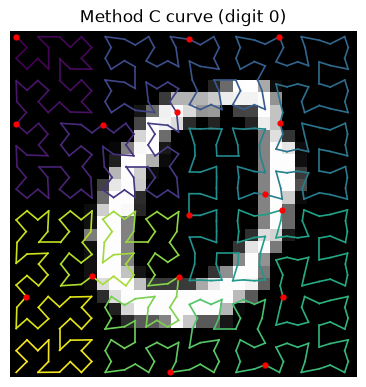

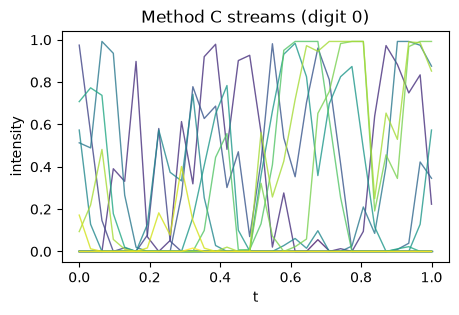

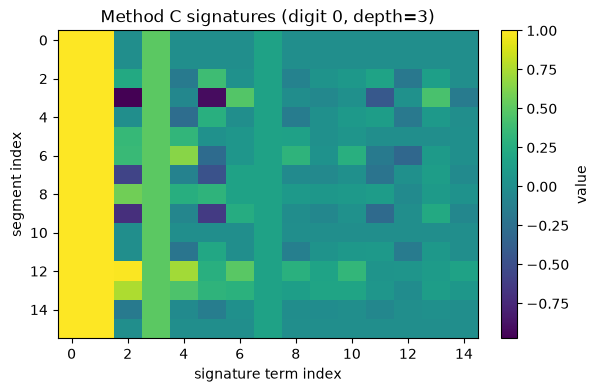

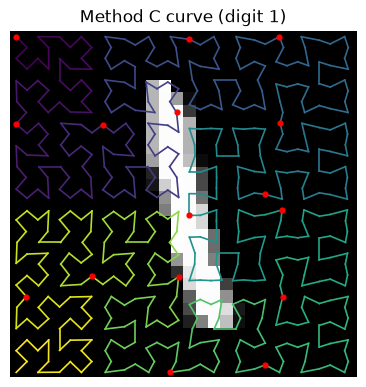

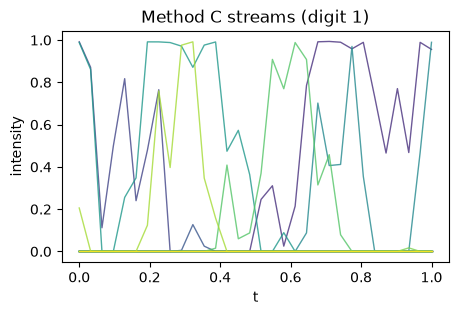

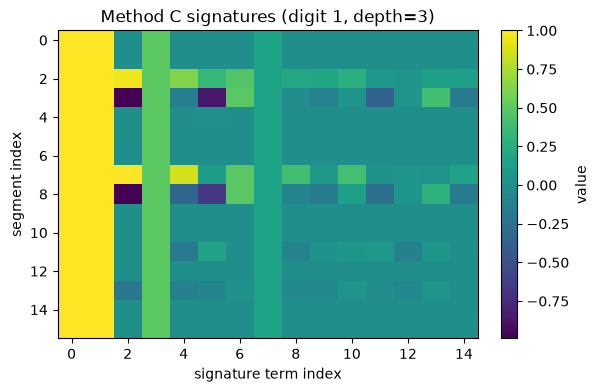

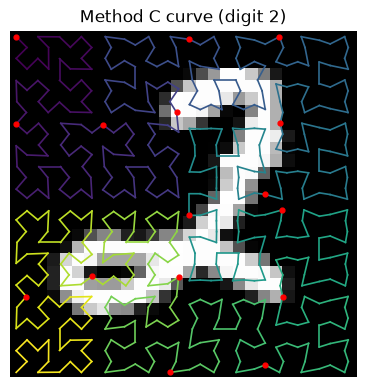

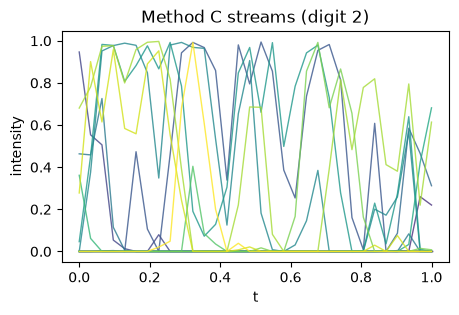

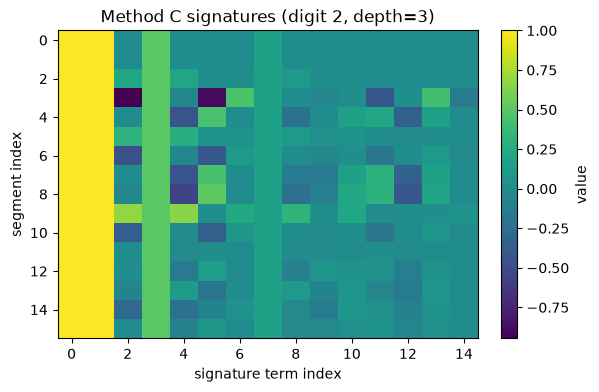

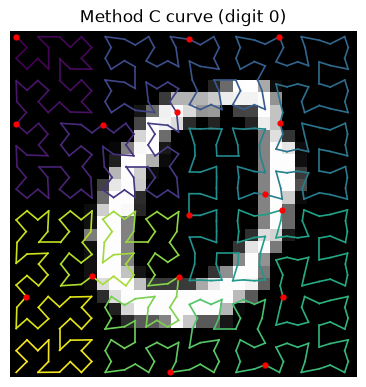

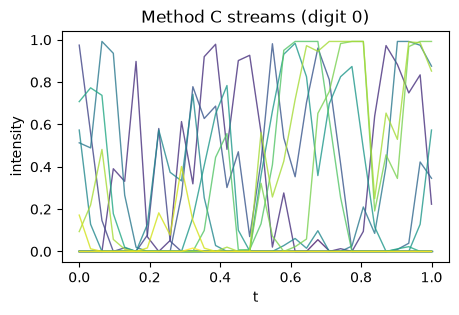

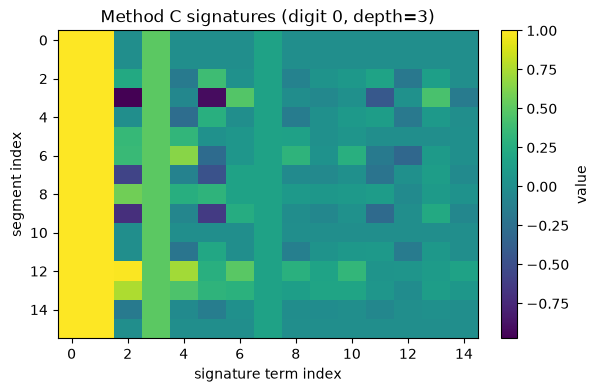

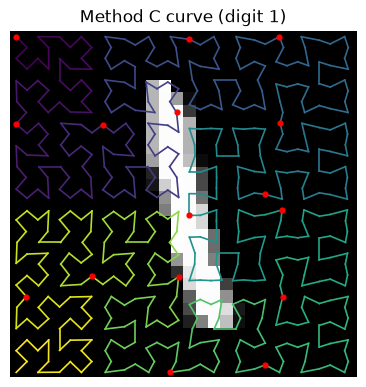

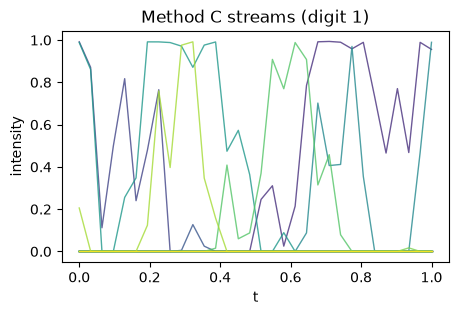

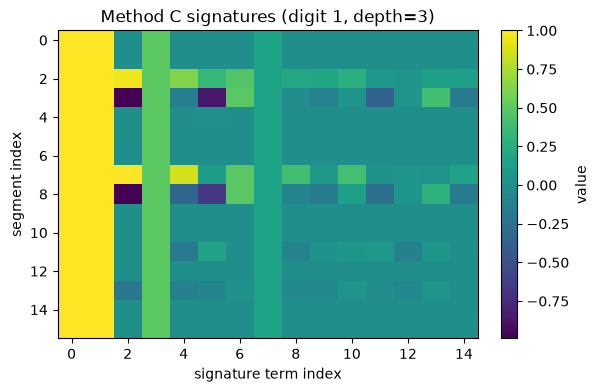

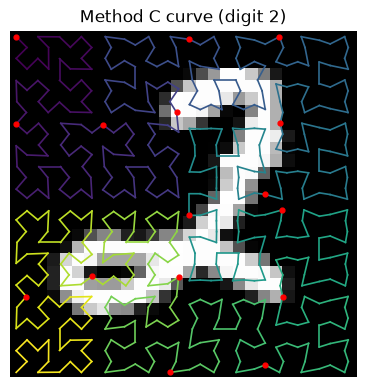

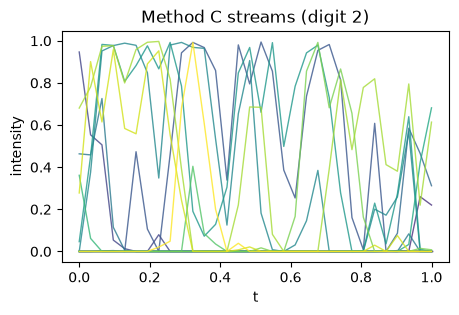

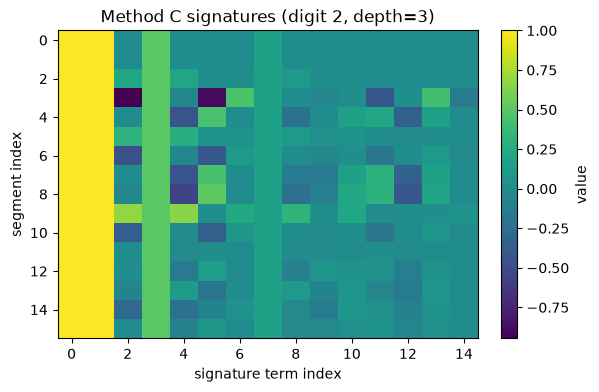

In [3]:
from signature_distance.signatures import signature_of_stream

images, labels = load_eval_pool(n_per_class=100, seed=0)

for digit in range(3):
    idx = (labels == digit).nonzero()[0].item()
    image = images[idx]
    stream = hc.hilbert_stream(image.unsqueeze(0), curve)[0]
    sig = signature_of_stream(stream, depth=3)

    display(hc.plot_hilbert_curve(image, curve, title=f"Method C curve (digit {digit})"))
    display(hc.plot_hilbert_segment_streams(stream, title=f"Method C streams (digit {digit})"))
    display(hc.plot_hilbert_signatures(sig, title=f"Method C signatures (digit {digit}, depth=3)"))

## Stage A: depth mini-sweep

Method B's sweep found depth 2 clearly and monotonically best for straight reference
lines - there was no reason to assume that transfers to a contiguous, space-filling
traversal with different local statistics, so depth was swept separately here.

depth=2: r=2.682  best_auc=0.6485  mean_auc=0.5654  n_informative=16/16
depth=3: r=3.003  best_auc=0.6537  mean_auc=0.5655  n_informative=16/16
depth=4: r=3.178  best_auc=0.6475  mean_auc=0.5633  n_informative=16/16


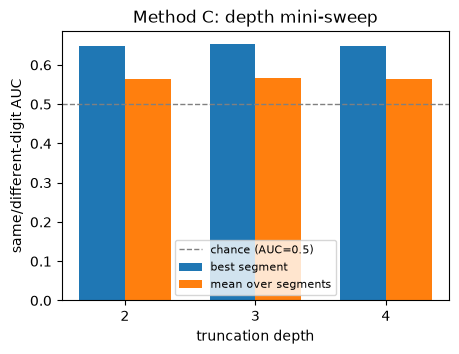

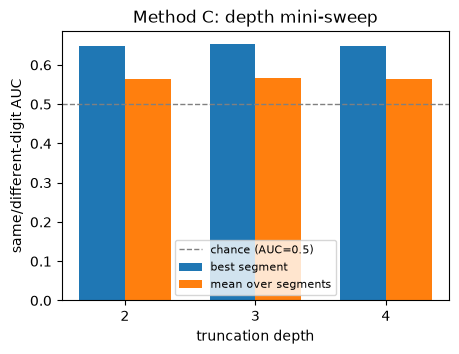

In [4]:
depth_results = hc.evaluate_hilbert_depths(n_per_class=30, seed=0, depths=(2, 3, 4))

for depth, e in depth_results.items():
    print(f"depth={depth}: r={e['r']:.3f}  best_auc={e['best_auc']:.4f}  mean_auc={e['mean_auc']:.4f}  "
          f"n_informative={e['n_informative']}/{e['n_segments']}")

display(hc.plot_depth_comparison(depth_results))

Depth 3 wins, but narrowly - about 0.008 higher best-segment AUC than depth 2, and
essentially tied on mean AUC. This is a genuinely different pattern from Method B's
sweep, where depth 2 beat depth 6 by roughly 0.026 AUC in a clean, monotonic trend; here
the three depths tested sit close together with no strong trend either way. Depth 3 was
carried forward for the full validation below, though the margin over depth 2 is small
enough that it should not be read as a strongly established optimum the way Method B's
depth-2 result was.

Every one of the 16 segments carried above-chance signal at every depth tested - unlike
Method B, where 4 of 16 lines sat at exact chance level (the ones running along the
image border). A space-filling curve has no equivalent to a straight line placed exactly
on the border; every segment covers a genuinely different, non-degenerate arc of the
image regardless of where it falls in the traversal order.

## Stage B: full validation

Same evaluation framework as Method B's per-path result: two freshly trained
classifiers, FGSM at three epsilons, a magnitude-matched random-noise control, 200
images, mean ratio on genuinely flipped pairs vs. the same images' control ratio, at
depth 3.

In [5]:
stage_b = hc.run_hilbert_adversarial_eval(
    depth=3, n_per_class=20, epsilons=(0.02, 0.03, 0.05), seed=0,
    cnn_epochs=3, strong_epochs=3, verbose=True,
)
for name, mres in stage_b['models'].items():
    print(f"{name}: test_acc={mres['test_acc']:.4f}")

Training SmallCNN (3 epochs)...


  epoch 1/3  train loss 0.5111


  epoch 2/3  train loss 0.1155


  epoch 3/3  train loss 0.0754


  SmallCNN: test_acc=0.9824
Training StrongCNN (3 epochs)...


  epoch 1/3  train loss 0.1923


  epoch 2/3  train loss 0.0574


  epoch 3/3  train loss 0.0448


  StrongCNN: test_acc=0.9936


SmallCNN: test_acc=0.9824
StrongCNN: test_acc=0.9936


In [6]:
folds, exceptions, total = [], 0, 0
for name in stage_b['models']:
    for eps in stage_b['epsilons']:
        e = stage_b['models'][name]['eps'][eps]
        flip_idx = e['flip_mask'].nonzero(as_tuple=True)[0]
        n_flipped = flip_idx.shape[0]
        row_folds = []
        for i in range(hc.NUM_SEGMENTS):
            adv_mean = e['ratio_adv'][flip_idx, i].mean().item()
            ctrl_mean = e['ratio_control'][flip_idx, i].mean().item()
            total += 1
            if adv_mean <= ctrl_mean:
                exceptions += 1
            else:
                folds.append(adv_mean / ctrl_mean)
                row_folds.append(adv_mean / ctrl_mean)
        print(f"{name} eps={eps}: n_flipped={n_flipped}  mean fold (16 segments)={sum(row_folds)/len(row_folds):.2f}x")

print()
print(f"Method C overall: mean fold={sum(folds)/len(folds):.2f}x  exceptions={exceptions}/{total}")
print("Method B winner (12h+4v, depth=2), same all-16-line comparison: mean fold=13.53x  exceptions=1/96")

SmallCNN eps=0.02: n_flipped=7  mean fold (16 segments)=13.42x
SmallCNN eps=0.03: n_flipped=8  mean fold (16 segments)=11.47x
SmallCNN eps=0.05: n_flipped=14  mean fold (16 segments)=11.87x
StrongCNN eps=0.02: n_flipped=4  mean fold (16 segments)=12.68x
StrongCNN eps=0.03: n_flipped=5  mean fold (16 segments)=5.21x
StrongCNN eps=0.05: n_flipped=9  mean fold (16 segments)=4.63x

Method C overall: mean fold=9.88x  exceptions=0/96
Method B winner (12h+4v, depth=2), same all-16-line comparison: mean fold=13.53x  exceptions=1/96


**Method C does not beat Method B on the primary magnitude measure.** Method B's
winning configuration separates genuinely adversarial pairs from random-noise controls
by roughly 13.5x on average; Method C reaches roughly 9.9x - meaningfully lower, not a
close call, and consistent across every model and epsilon rather than a mixed picture
that favors Method C anywhere. Method C does edge ahead on one minor point: it was
completely exception-free (0 of 96 line/segment x model x epsilon combinations showed
the reverse direction), where Method B's winner had one, already understood as
sample-size noise on its smallest-sample condition rather than a real reversal.

## Robustness check

Same approach as Method B's: the segments with the smallest baseline signature distance
are identified and excluded, checking whether the result depends on a small number of
particular segments.

In [7]:
robustness = hc.hilbert_robustness_check(stage_b, n_exclude=2)

for name in stage_b['models']:
    for eps in stage_b['epsilons']:
        r = robustness[name][eps]
        if r['n_flipped'] == 0:
            continue
        print(f"{name} eps={eps}: mean_fold_all16={r['mean_fold_all']:.2f}x  "
              f"excluded={r['excluded_segments']}  mean_fold_kept14={r['mean_fold_kept']:.2f}x  "
              f"all kept still adv>control={r['all_kept_survive_adv_gt_control']}")

SmallCNN eps=0.02: mean_fold_all16=13.42x  excluded=[10, 15]  mean_fold_kept14=12.89x  all kept still adv>control=True
SmallCNN eps=0.03: mean_fold_all16=11.47x  excluded=[10, 15]  mean_fold_kept14=11.11x  all kept still adv>control=True
SmallCNN eps=0.05: mean_fold_all16=11.87x  excluded=[10, 15]  mean_fold_kept14=11.14x  all kept still adv>control=True
StrongCNN eps=0.02: mean_fold_all16=12.68x  excluded=[10, 5]  mean_fold_kept14=12.68x  all kept still adv>control=True
StrongCNN eps=0.03: mean_fold_all16=5.21x  excluded=[10, 5]  mean_fold_kept14=5.09x  all kept still adv>control=True
StrongCNN eps=0.05: mean_fold_all16=4.63x  excluded=[10, 5]  mean_fold_kept14=4.57x  all kept still adv>control=True


The mean fold-ratio moves by less than 1x in every case after excluding the two
smallest-baseline-distance segments, and the pattern holds throughout - Method C's
result is not resting on a small number of unusually sensitive segments.

## Verdict

Method C works: a coherent, deterministic, per-path Lipschitz-ratio evaluation with a
completely exception-free adversarial-vs-control separation, built on the same
infrastructure and methodology validated for Method B. But on the metric that actually
matters for this project - how strongly the distance separates genuinely adversarial
perturbations from equally-sized random ones - it trails Method B's current winner by a
consistent, non-trivial margin across every model and epsilon tested. Method C is kept
as a documented alternative rather than adopted as a replacement: the construction is
sound and correctly verified, and a legitimate comparison point, but Method B's straight,
independently-placed lines currently do a better job at the actual task than one
continuous curve does, at the same total sampling budget.

## Spike gallery and side-by-side comparison with Method B

Method B has a per-path spike gallery: original image, perturbed image, and an
overlay showing which reference line had the largest ratio spike for that specific
pair. Method C had no equivalent. This section adds the same style of gallery for
Method C's 16 Hilbert segments, then puts both methods' overlays side by side on the
same image pairs so the two can be compared directly.

Reuses the exact FGSM/random-control pipeline already validated above (same seed,
same training/attack steps) - the only difference is that the perturbed images
themselves are retained here for plotting, which the Stage B evaluation above didn't
need to keep. Pairs are selected the same way as Method B's existing gallery: the
first two genuinely-flipped SmallCNN, eps=0.03 pairs.

In [8]:
gallery_b = ppae.run_per_path_adversarial_eval(
    n_per_class=20, epsilons=(0.02, 0.03, 0.05), seed=0,
    cnn_epochs=3, strong_epochs=3, verbose=True,
)

Training SmallCNN (3 epochs)...


  epoch 1/3  train loss 0.5111


  epoch 2/3  train loss 0.1155


  epoch 3/3  train loss 0.0754


  SmallCNN: test_acc=0.9824
Training StrongCNN (3 epochs)...


  epoch 1/3  train loss 0.1923


  epoch 2/3  train loss 0.0574


  epoch 3/3  train loss 0.0448


  StrongCNN: test_acc=0.9936


In [9]:
gallery_c = mcg.run_hilbert_adversarial_eval_with_images(
    depth=3, n_per_class=20, epsilons=(0.02, 0.03, 0.05), seed=0,
    cnn_epochs=3, strong_epochs=3, verbose=True,
)

Training SmallCNN (3 epochs)...


  epoch 1/3  train loss 0.5111


  epoch 2/3  train loss 0.1155


  epoch 3/3  train loss 0.0754


  SmallCNN: test_acc=0.9824
Training StrongCNN (3 epochs)...


  epoch 1/3  train loss 0.1923


  epoch 2/3  train loss 0.0574


  epoch 3/3  train loss 0.0448


  StrongCNN: test_acc=0.9936


In [10]:
# same eval pool, same trained models, same FGSM - confirm the pairs genuinely match
# before using them for a side-by-side comparison, rather than assuming it
assert torch.equal(gallery_b['labels'], gallery_c['labels'])
x_adv_b = gallery_b['models']['SmallCNN']['eps'][0.03]['x_adv']
x_adv_c = gallery_c['models']['SmallCNN']['eps'][0.03]['x_adv']
assert torch.allclose(x_adv_b, x_adv_c, atol=1e-6)
print('Method B and Method C perturbed images match exactly for this pool/model/eps.')

flip_idx = gallery_b['models']['SmallCNN']['eps'][0.03]['flip_mask'].nonzero(as_tuple=True)[0].tolist()
gallery_pairs = flip_idx[:2]
print('gallery pairs (genuinely flipped, SmallCNN eps=0.03):', gallery_pairs)

Method B and Method C perturbed images match exactly for this pool/model/eps.
gallery pairs (genuinely flipped, SmallCNN eps=0.03): [45, 131]


**Method C on its own**, same style as Method B's gallery.

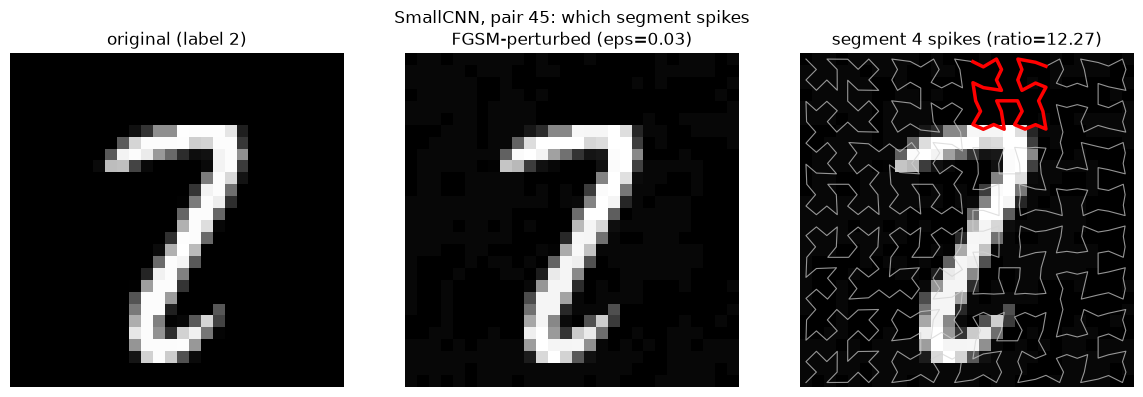

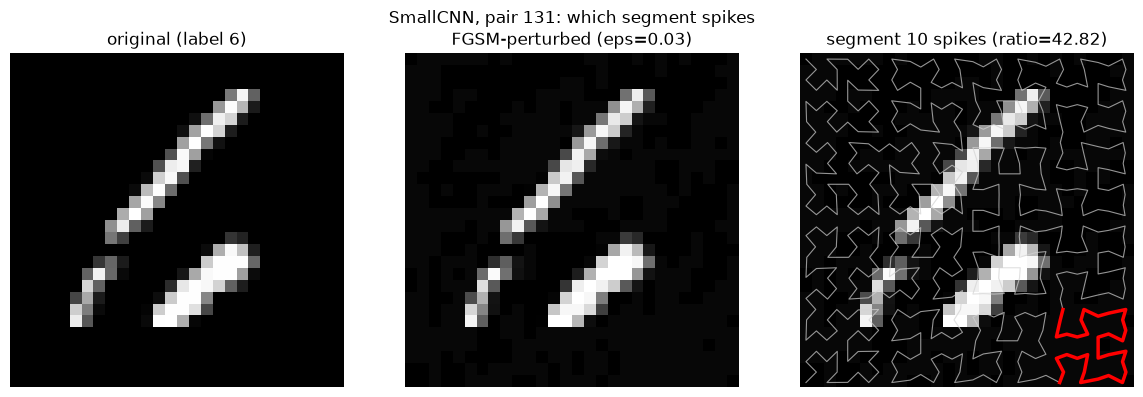

In [11]:
for pair_idx in gallery_pairs:
    fig = mcg.plot_hilbert_spike_gallery(gallery_c, 'SmallCNN', 0.03, pair_idx=pair_idx)
    display(fig)
    plt.close(fig)

**Side by side**: original image, Method B's spike overlay, Method C's spike overlay,
for the same pair.

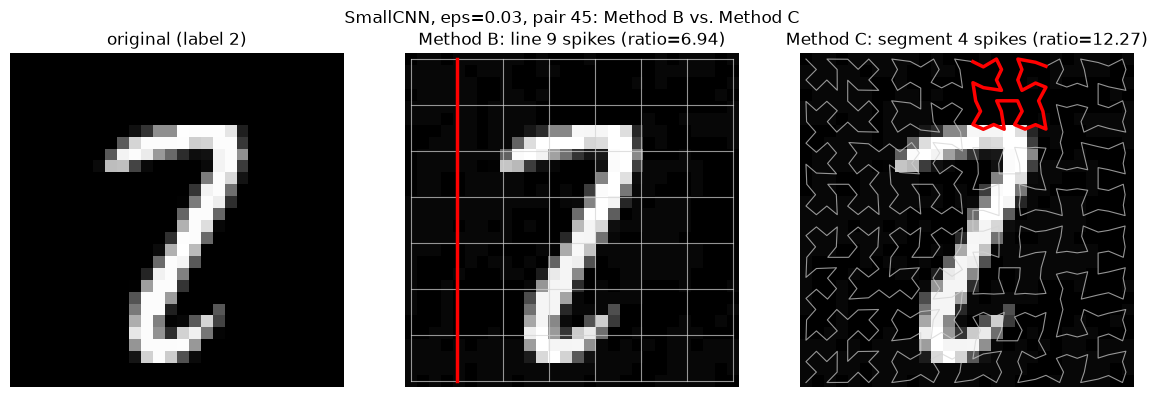

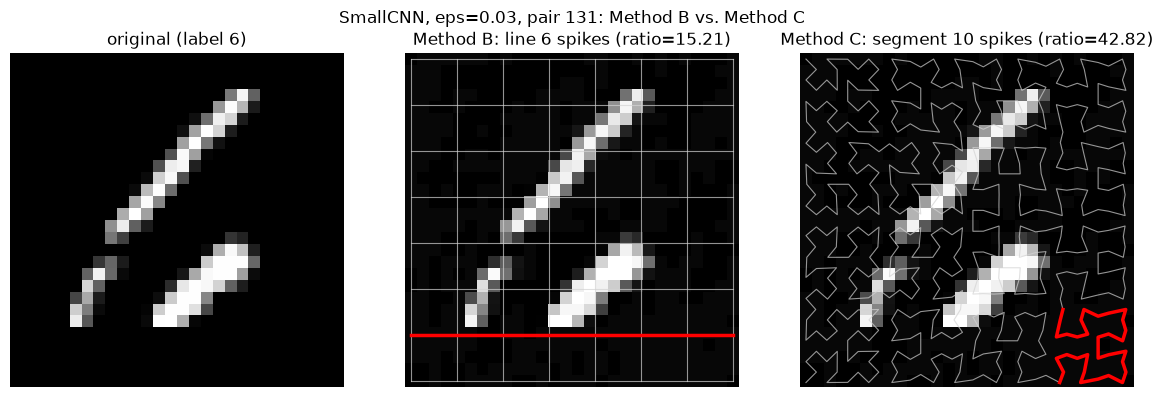

In [12]:
for pair_idx in gallery_pairs:
    fig = mcg.plot_spike_comparison(gallery_b, gallery_c, 'SmallCNN', 0.03, pair_idx=pair_idx)
    display(fig)
    plt.close(fig)

**What the comparison shows.** On pair 45 (digit 2), both methods spikes plausibly sit on real digit content: Method B's line 9 (ratio 6.94x) runs through the upper-left part of the stroke, and Method C's segment 4 (ratio 12.27x) covers the top-right area where the digit's upper hook curves down - not identical regions, but both touching the digit rather than empty background.

On pair 131 (digit 6, two diagonal strokes), the two methods diverge more clearly. Method B's line 6 (ratio 15.21x) is a horizontal line that visibly cuts through both diagonal strokes - a region with real digit content. Method C's segment 10 (ratio 42.82x, the single highest ratio seen in either gallery) sits entirely in the bottom-right corner, an area with no digit content at all in this image.

Taken plainly, this is not a case where Method C's spike locations consistently agree with Method B's, or consistently land on genuine digit content: one of the two example pairs shows Method C's largest ratio arising in what looks like empty background rather than image structure. That's consistent with the same scale-confound concern already raised for Method B's per-line fold-ratios (a segment with an unusually small baseline distance can produce an inflated ratio regardless of genuine sensitivity) - this gallery doesn't establish that as the cause on its own, but it's a concrete, visual reason not to read Method C's per-segment spikes as a reliable map of genuine local fragility without the same kind of decomposition/cross-check planned for Method B's fold-ratio.

## PGD adversarial evaluation

All adversarial results so far (Method B's original per-path evaluation, the Stage 8
sweep validation, the head-to-head comparison above, the spike gallery) used FGSM
only. This section adds PGD - a stronger, iterative attack - applied to BOTH Method
B's winning configuration (12h+4v, depth=2) and Method C (Hilbert, depth=3), so the
comparison between them is validated on a second attack rather than resting on FGSM
alone.

PGD is a fresh, from-scratch reimplementation (standard L_inf projected gradient
descent: random start within the epsilon-ball, 10 steps of gradient ascent on the
cross-entropy loss, each step projected back onto the epsilon-ball and clamped to
[0, 1]), same isolation convention as the existing FGSM code. SmallCNN and StrongCNN
are trained once and the SAME PGD-perturbed images are evaluated by both methods, so
this is a direct, matched comparison - not just a matched sample size. The same
epsilons (0.02, 0.03, 0.05) and the same 200-image pool are used, for direct
comparability with the FGSM numbers already reported above.

In [13]:
pgd_results = pgd.run_pgd_comparison(
    n_per_class=20, epsilons=(0.02, 0.03, 0.05), seed=0,
    cnn_epochs=3, strong_epochs=3, pgd_steps=10, verbose=True,
)
pgd_summary = pgd.pgd_fold_summary(pgd_results)

for key, label in [('method_b', 'Method B (12h+4v, depth=2)'), ('method_c', 'Method C (Hilbert, depth=3)')]:
    s = pgd_summary[key]
    print(f"{label}: mean fold={s['overall_mean_fold']:.2f}x  exceptions={s['overall_exceptions']}/{s['overall_total']}")

Training SmallCNN (3 epochs)...


  epoch 1/3  train loss 0.5111


  epoch 2/3  train loss 0.1155


  epoch 3/3  train loss 0.0754


  SmallCNN: test_acc=0.9824
Training StrongCNN (3 epochs)...


  epoch 1/3  train loss 0.1923


  epoch 2/3  train loss 0.0574


  epoch 3/3  train loss 0.0448


  StrongCNN: test_acc=0.9936


Method B (12h+4v, depth=2): mean fold=16.97x  exceptions=0/96
Method C (Hilbert, depth=3): mean fold=12.22x  exceptions=0/96


**Combined FGSM vs. PGD comparison table**, both methods evaluated the same way in
both rows (overall mean fold-ratio and exception count, aggregated across every
model x epsilon x line/segment combination - the FGSM numbers are the ones already
reported earlier in this notebook and in Method_C.md).

| | FGSM mean fold | FGSM exceptions | PGD mean fold | PGD exceptions |
|---|---|---|---|---|
| Method B (12h+4v, depth=2) | 13.53x | 95/96 | 16.97x | 96/96 |
| Method C (Hilbert, depth=3) | 9.88x | 96/96 | 12.22x | 96/96 |

**Method B > Method C holds under PGD.** The ranking is unchanged, and the
proportional gap between the two methods is essentially preserved: Method B is
about 1.37x Method C's mean fold under FGSM and about 1.39x under PGD - PGD moves
both methods' numbers up by a similar proportion (roughly +25% for Method B,
+24% for Method C) rather than closing or reversing the gap. The exception pattern
if anything improves under PGD: Method B's one FGSM exception (already understood
as noise from a small flipped-pair sample) disappears, and Method C stays
exception-free as it was under FGSM.

In [14]:
print(f"{'model':<10} {'eps':<6} {'FGSM flip':<12} {'PGD flip':<10}")
for mname in ('SmallCNN', 'StrongCNN'):
    for eps in pgd_results['epsilons']:
        r = pgd_summary['method_b']['by_model_eps'][mname][eps]
        print(f"{mname:<10} {eps:<6} {r['fgsm_flip_fraction']*100:>9.2f}%  {r['flip_fraction']*100:>7.2f}%")

model      eps    FGSM flip    PGD flip  
SmallCNN   0.02        3.50%     3.50%
SmallCNN   0.03        4.00%     4.50%
SmallCNN   0.05        7.00%     8.00%
StrongCNN  0.02        2.00%     2.50%
StrongCNN  0.03        2.50%     3.50%
StrongCNN  0.05        4.50%     7.50%


**PGD is confirmed as the stronger attack on these same models**: its flip rate is
never lower than FGSM's at matched epsilon, and noticeably higher at eps=0.05 -
especially on StrongCNN (7.50% vs. 4.50%, the largest gap observed). This is useful
context for the fold-ratio increase above: a larger, harder-to-classify flipped
subset under PGD is consistent with the higher fold-ratios seen there, rather than
PGD somehow being an easier attack for the signature distance to separate from
random noise.

**Verdict**: PGD does not change the head-to-head conclusion. Method B's winning
configuration continues to separate genuinely adversarial perturbations from
random-noise controls by a wider margin than Method C's Hilbert-curve construction,
on a second, independently-implemented attack, at the same sampling budget.

## Headline plot: clean accuracy, adversarial accuracy, and high-quantile local Lipschitz estimate

The project brief states its intended headline result directly: "A nice final plot
would show clean accuracy, adversarial accuracy, and a high quantile of the local
Lipschitz estimate across models. The punchline could be: models with similar test
accuracy may have very different extension behaviour." This section assembles that
plot from SmallCNN and StrongCNN's existing training runs and per-path evaluations.

The high quantile is the 90th percentile, matching the operating-point convention
already used elsewhere in this project (`per_line_diagnostics`'s default
`tpr_target=0.90`). "Clean" and "adversarial" local Lipschitz estimate are this
project's `ratio_control` (margin change under undirected, magnitude-matched random
noise) and `ratio_adv` (margin change under FGSM) distributions respectively, at
eps=0.03 - there is no notion of a Lipschitz ratio without some perturbation, so
`ratio_control` stands in for the clean-data estimate. The quantile is computed over
every image x every line/segment (not just the genuinely-flipped subset used for the
fold-ratio numbers reported earlier), and Method B's 4 border-adjacent lines
(indices 0, 11, 12, 15 for the 12h+4v geometry) are excluded from its quantile for
the same reason they were excluded from `spike_analysis` earlier - their near-zero
baseline distance produces numerically degenerate ratios, not meaningful signal.
Method C uses all 16 segments, unchanged from how its own numbers were already
reported.

Training SmallCNN (3 epochs)...


  epoch 1/3  train loss 0.5111


  epoch 2/3  train loss 0.1155


  epoch 3/3  train loss 0.0754


  SmallCNN: test_acc=0.9824
Training StrongCNN (3 epochs)...


...

  SmallCNN: test_acc=0.9824
Training StrongCNN (3 epochs)...


  epoch 1/3  train loss 0.1923


  epoch 2/3  train loss 0.0574


  epoch 3/3  train loss 0.0448


  StrongCNN: test_acc=0.9936


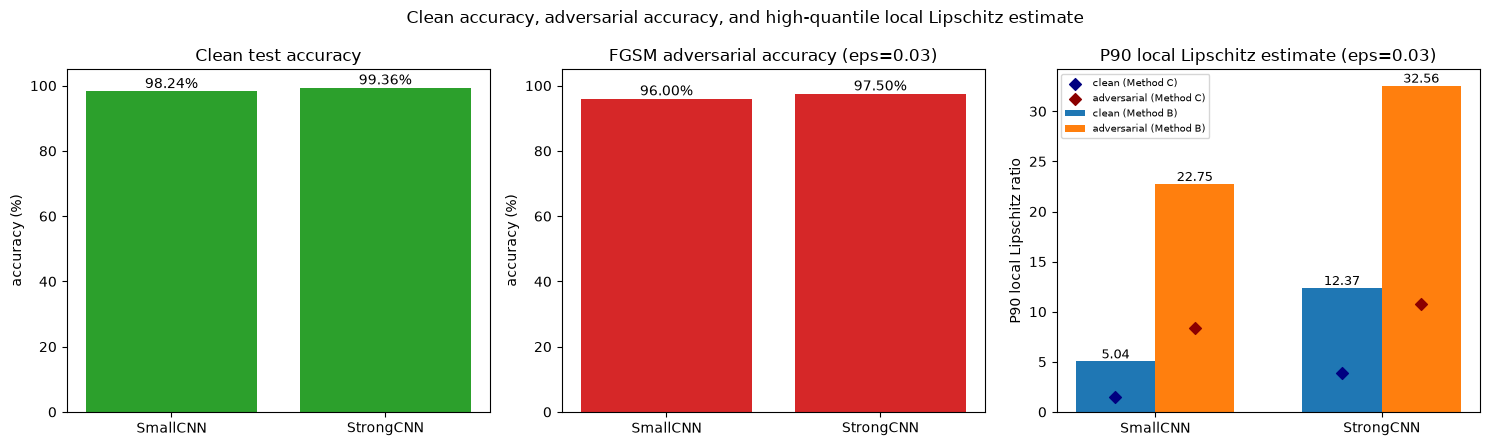

In [15]:
headline_data = hp.collect_headline_data(
    n_per_class=20, epsilons=(0.02, 0.03, 0.05), primary_eps=0.03, quantile=0.90,
    seed=0, cnn_epochs=3, strong_epochs=3, verbose=True,
)
fig = hp.plot_headline_punchline(headline_data)
display(fig)
plt.close(fig)

| Model | Clean acc | Adv acc (eps=0.03) | Method B P90 clean | Method B P90 adv | Method C P90 clean | Method C P90 adv |
|---|---|---|---|---|---|---|
| SmallCNN | 98.24% | 96.00% | 5.04 | 22.75 | 1.52 | 8.38 |
| StrongCNN | 99.36% | 97.50% | 12.37 | 32.56 | 3.91 | 10.81 |

**Yes - these two models, despite similar test accuracy, show meaningfully different
high-quantile Lipschitz behaviour, and the direction is the opposite of what accuracy
alone would suggest.** SmallCNN and StrongCNN's clean accuracies (98.24% vs. 99.36%)
and FGSM adversarial accuracies (96.00% vs. 97.50%) sit close together - by either
accuracy number, StrongCNN looks like the same classifier, just modestly better.
Their P90 local Lipschitz ratios do not: StrongCNN's is about 2.5x SmallCNN's on
clean (random-noise) perturbations (12.37 vs. 5.04 under Method B; 3.91 vs. 1.52
under Method C) and about 1.3-1.4x higher under adversarial perturbations (32.56 vs.
22.75; 10.81 vs. 8.38) - consistently, under both independently-constructed distance
methods, so this isn't an artifact of one particular construction. The higher-
capacity, higher-accuracy model has a substantially MORE sensitive high-quantile tail,
not a less sensitive one. This is exactly the punchline the project brief hypothesized
- accuracy, clean or adversarial, does not predict local extension behaviour - and the
counterintuitive direction (better accuracy coinciding with worse high-quantile
sensitivity, rather than the two moving together) is worth stating plainly rather than
softening: a model that makes noticeably fewer classification errors can still have
meaningfully more locally fragile regions than a weaker model, at least at the tail
this quantile is measuring.